✅ Setup complete.
orders:      (646945, 8)
order_items: (714669, 7)
shipments:   (566067, 4)
returns:     (39939, 7)
inventory:   (60247, 17)
products:    (2412, 8)
✅ Data loaded and merged successfully.

📦 SECTION 1: REORDER POINT OPTIMIZATION

=== Top 15 Products — Reorder Point Recommendation ===
shape: (15, 6)
┌─────────────────┬────────────┬─────────────────┬─────────────────┬──────────────┬────────────────┐
│ product_name    ┆ category   ┆ avg_daily_deman ┆ avg_lead_time_d ┆ safety_stock ┆ recommended_re │
│ ---             ┆ ---        ┆ d               ┆ ays             ┆ ---          ┆ order_point    │
│ str             ┆ str        ┆ ---             ┆ ---             ┆ f64          ┆ ---            │
│                 ┆            ┆ f64             ┆ f64             ┆              ┆ f64            │
╞═════════════════╪════════════╪═════════════════╪═════════════════╪══════════════╪════════════════╡
│ SaigonFlex      ┆ Streetwear ┆ 5.383908        ┆ 5.970511        ┆ 18.036613

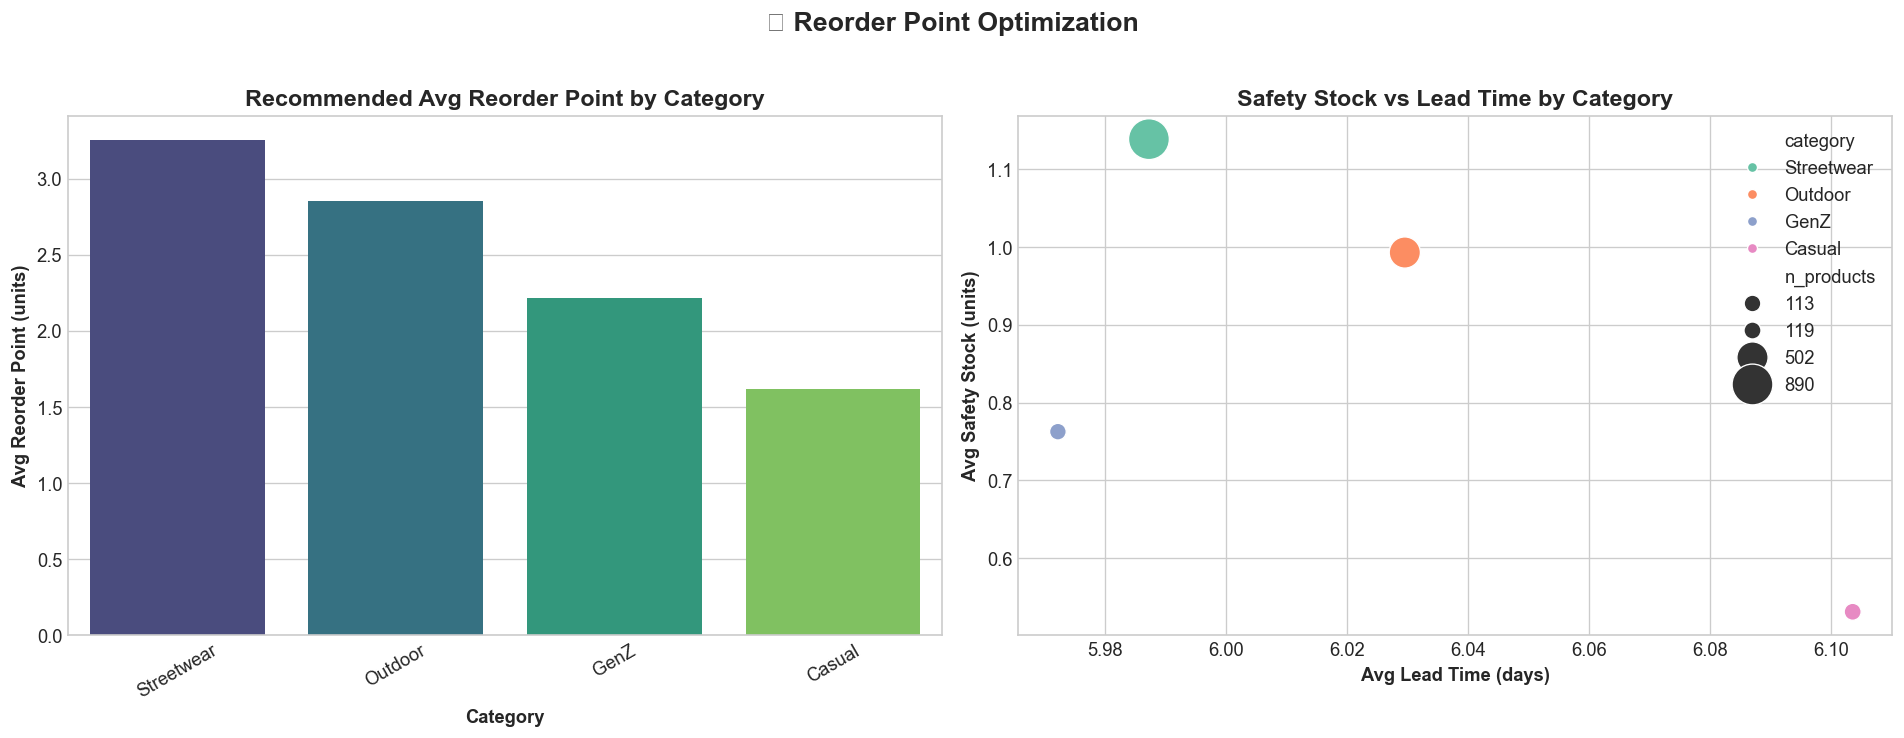


🚚 SECTION 2: DELIVERY TIME REDUCTION

=== Delivery Time Gap — Benchmark Analysis ===
Benchmark (fastest city): Can Tho — 5.97 days
shape: (42, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ city       ┆ avg_delive ┆ median_del ┆ avg_days_ ┆ avg_days_ ┆ order_cou ┆ gap_vs_be ┆ potential │
│ ---        ┆ ry_days    ┆ ivery_days ┆ to_ship   ┆ in_transi ┆ nt        ┆ st_days   ┆ _improvem │
│ str        ┆ ---        ┆ ---        ┆ ---       ┆ t         ┆ ---       ┆ ---       ┆ ent_days  │
│            ┆ f64        ┆ f64        ┆ f64       ┆ ---       ┆ u32       ┆ f64       ┆ ---       │
│            ┆            ┆            ┆           ┆ f64       ┆           ┆           ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ Vung Tau   ┆ 6.038846   ┆ 6.0        ┆ 1.50462   ┆ 4.534226  ┆ 10606     ┆ 0.07      ┆ 0.04      │
│ Bien Hoa   ┆ 6.031333   ┆ 6.0        ┆ 1.49

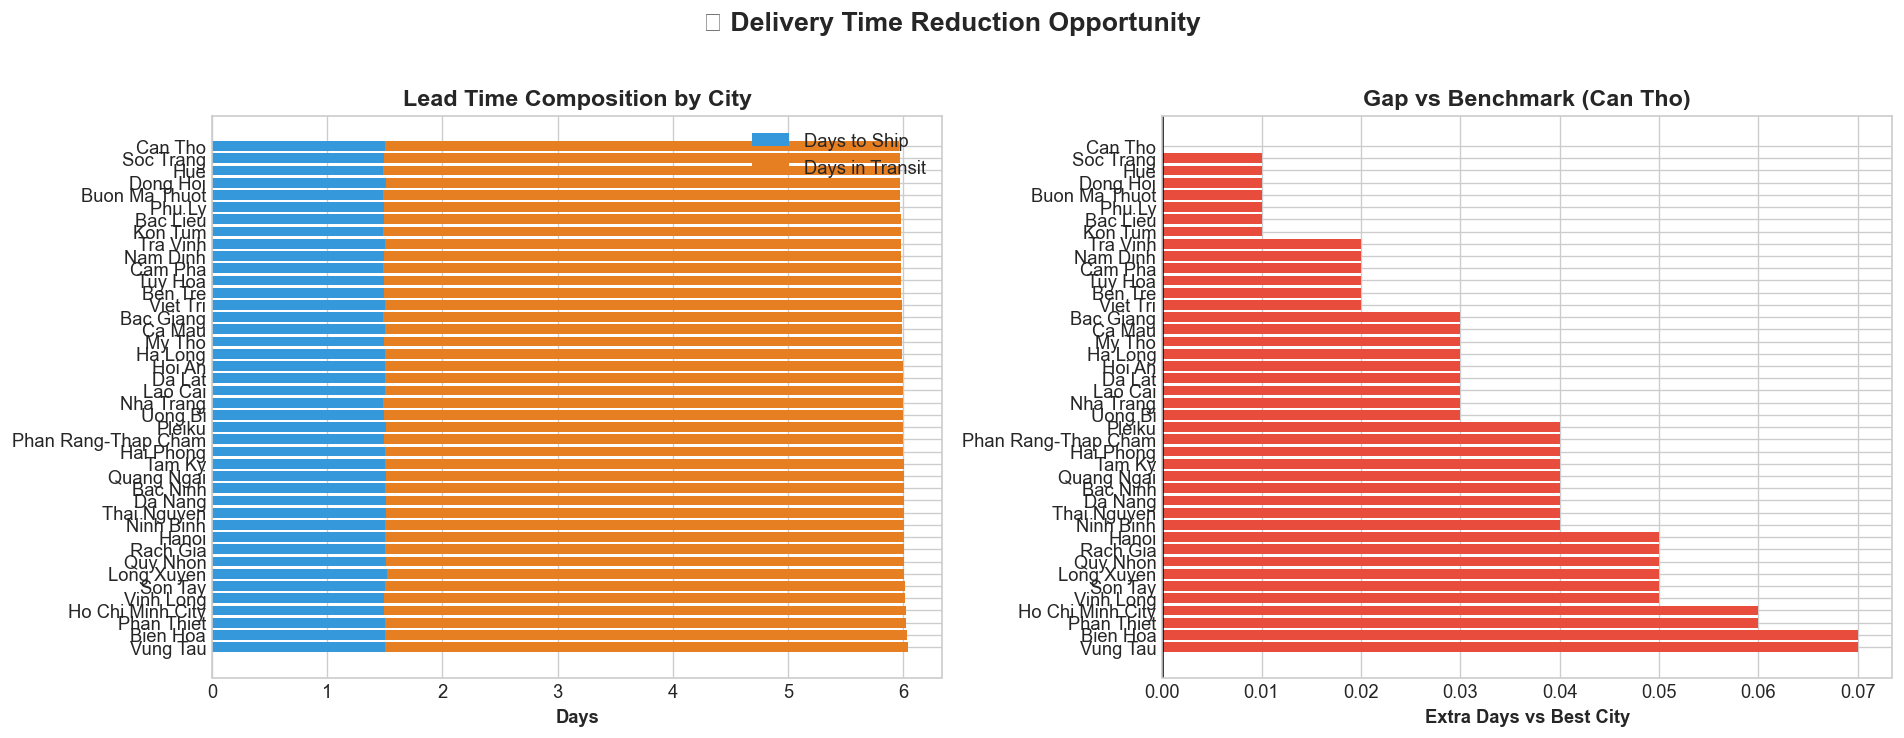


=== 🎯 Prescriptive Recommendations (Delivery) ===
  ✅ Tất cả thành phố có thời gian giao hàng tương đương.

📏 SECTION 3: SIZE GUIDE ROI ANALYSIS

=== Return Cost by Reason ===
shape: (5, 4)
┌──────────────────┬──────────────┬───────────────────┬───────────────────────┐
│ return_reason    ┆ return_count ┆ total_refund_cost ┆ avg_refund_per_return │
│ ---              ┆ ---          ┆ ---               ┆ ---                   │
│ str              ┆ u32          ┆ f64               ┆ f64                   │
╞══════════════════╪══════════════╪═══════════════════╪═══════════════════════╡
│ wrong_size       ┆ 13970        ┆ 1.7675e8          ┆ 12651.813983          │
│ defective        ┆ 8020         ┆ 1.0360e8          ┆ 12917.59891           │
│ not_as_described ┆ 7036         ┆ 9.0656e7          ┆ 12884.645144          │
│ changed_mind     ┆ 6931         ┆ 8.9722e7          ┆ 12944.994806          │
│ late_delivery    ┆ 3986         ┆ 4.9937e7          ┆ 12528.151721          │
└────────

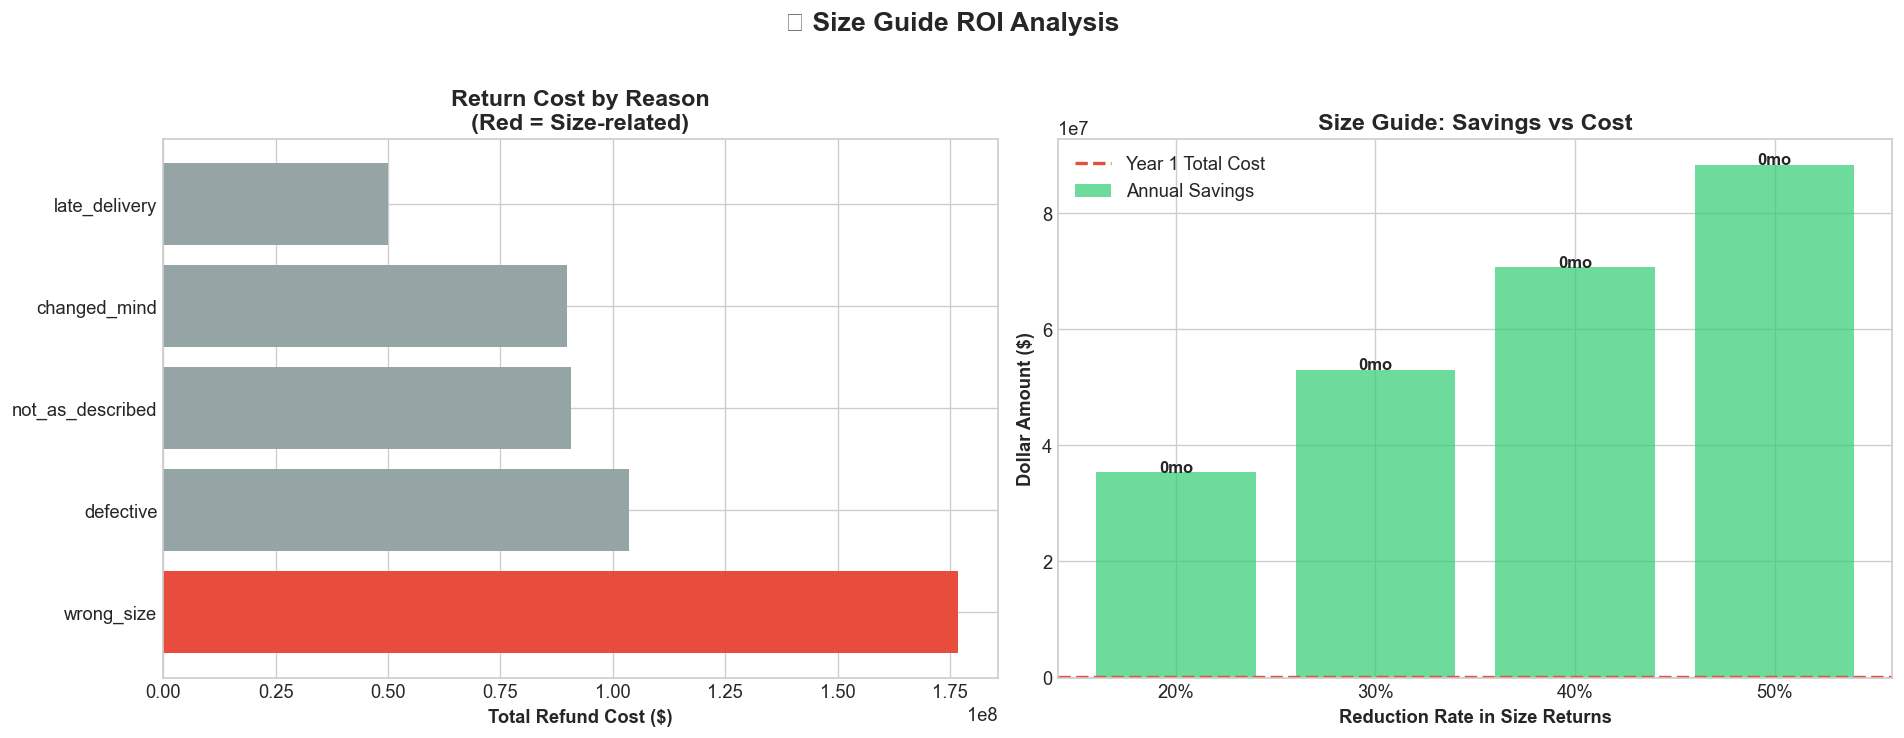


📝 PRESCRIPTIVE SUMMARY — Module ❹ (Supply Chain)

🎯 ACTION ITEMS:

1. REORDER POINT OPTIMIZATION
   - Triển khai hệ thống Reorder Point tự động dựa trên:
     ROP = (Avg Daily Demand × Avg Lead Time) + Safety Stock
   - Safety Stock ở Service Level 95%% (Z = 1.65)
   - Ưu tiên Category có demand cao và lead time biến động lớn

2. DELIVERY TIME REDUCTION
   - Xác định thành phố bottleneck (gap > 1 ngày so với benchmark)
   - Nếu Processing Time là bottleneck → Tối ưu warehouse operations
   - Nếu Transit Time là bottleneck → Đàm phán carrier hoặc mở hub mới

3. SIZE GUIDE ROI
   - Size-related returns chiếm tỷ trọng đáng kể trong tổng return cost
   - Với mức giảm 30%% returns, Size Guide có thể hoàn vốn trong vòng 1-2 năm
   - Đề xuất: Pilot với top 5 categories có return rate cao nhất

📊 Figures saved to: /Users/khanhnq35/Documents/Datathon_Outliers/figures


In [2]:
"""
Day 5: EDA Prescriptive — Module ❹ (Supply Chain Prescriptive)
Owner: Nguyễn Quốc Khánh (Tech Lead)
Output: 04_M4_supply_prescriptive.ipynb

Mục tiêu:
  1. Đề xuất Reorder Point tối ưu cho từng sản phẩm/category.
  2. Phân tích & đề xuất giảm Delivery Time theo vùng.
  3. Tính ROI cho giải pháp Size Guide dựa trên Return data.
"""

# ============================================================
# CELL 1: Setup & Imports
# ============================================================
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import os
import warnings

# %matplotlib inline

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("..", "src")))
sys.path.append(os.path.abspath("src"))

try:
    from data_loader import DataLoader
except ImportError:
    print("Warning: data_loader module not found, make sure src/data_loader.py exists.")

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 14})

FIGURES_DIR = os.path.abspath(os.path.join("..", "figures"))
os.makedirs(FIGURES_DIR, exist_ok=True)
print("✅ Setup complete.")


# ============================================================
# CELL 2: Load Data
# ============================================================
loader = DataLoader()

orders = loader.load("orders")
order_items = loader.load("order_items")
shipments = loader.load("shipments")
returns = loader.load("returns")
inventory = loader.load("inventory")
products = loader.load("products")
customers = loader.load("customers")

print(f"orders:      {orders.shape}")
print(f"order_items: {order_items.shape}")
print(f"shipments:   {shipments.shape}")
print(f"returns:     {returns.shape}")
print(f"inventory:   {inventory.shape}")
print(f"products:    {products.shape}")


# ============================================================
# CELL 3: Merge Domain DataFrames
# ============================================================
# Delivery DataFrame
df_delivery = orders.join(shipments, on="order_id", how="inner")
if "city" not in df_delivery.columns and "customer_id" in df_delivery.columns:
    df_delivery = df_delivery.join(
        customers.select(["customer_id", "city"]),
        on="customer_id",
        how="left",
    )

# Returns DataFrame
df_returns = returns.join(order_items, on=["order_id", "product_id"], how="left")

# Inventory DataFrame
df_inventory = inventory.join(products, on="product_id", how="left", suffix="_prod")

# Date Casting cho Delivery
date_cols = ["order_date", "ship_date", "delivery_date"]
for col in date_cols:
    if col in df_delivery.columns:
        try:
            df_delivery = df_delivery.with_columns(
                pl.col(col).str.strptime(pl.Date, "%Y-%m-%d", strict=False).cast(pl.Datetime)
            )
        except Exception:
            df_delivery = df_delivery.with_columns(pl.col(col).cast(pl.Datetime))

df_delivery = df_delivery.with_columns([
    ((pl.col("ship_date") - pl.col("order_date")).dt.total_days()).alias("days_to_ship"),
    ((pl.col("delivery_date") - pl.col("ship_date")).dt.total_days()).alias("days_in_transit"),
    ((pl.col("delivery_date") - pl.col("order_date")).dt.total_days()).alias("total_delivery_days"),
])

df_delivery_clean = df_delivery.filter(pl.col("total_delivery_days") >= 0)

print("✅ Data loaded and merged successfully.")

# ============================================================
# SECTION 1: REORDER POINT OPTIMIZATION
# ============================================================

# ============================================================
# CELL 4: 1.1 — Tính Average Daily Demand & Lead Time per Product
# ============================================================
print("\n" + "=" * 60)
print("📦 SECTION 1: REORDER POINT OPTIMIZATION")
print("=" * 60)

# Average daily demand (units sold) theo product_id từ inventory
# inventory snapshot hàng tháng: tổng units_sold / tổng số tháng → daily demand
product_demand = inventory.group_by("product_id").agg(
    pl.col("units_sold").sum().alias("total_units_sold"),
    pl.count().alias("n_snapshots"),  # mỗi snapshot ~ 1 tháng
).with_columns(
    (pl.col("total_units_sold") / (pl.col("n_snapshots") * 30)).alias("avg_daily_demand")
)

# Average lead time = average total_delivery_days theo product_id
avg_lead_time_per_product = (
    df_delivery_clean.join(order_items.select(["order_id", "product_id"]), on="order_id", how="left")
    .group_by("product_id")
    .agg(
        pl.col("total_delivery_days").mean().alias("avg_lead_time_days"),
        pl.col("total_delivery_days").std().alias("std_lead_time_days"),
    )
)

# Merge demand + lead time
reorder_analysis = product_demand.join(avg_lead_time_per_product, on="product_id", how="left")
reorder_analysis = reorder_analysis.join(
    products.select(["product_id", "product_name", "category", "price"]),
    on="product_id",
    how="left",
)

# Tính Reorder Point = (avg_daily_demand * avg_lead_time) + Safety Stock
# Safety Stock = Z * std_lead_time * avg_daily_demand (Z = 1.65 cho service level 95%)
Z_95 = 1.65
reorder_analysis = reorder_analysis.with_columns([
    (pl.col("avg_daily_demand") * pl.col("avg_lead_time_days")).alias("base_reorder_point"),
    (Z_95 * pl.col("std_lead_time_days").fill_null(0) * pl.col("avg_daily_demand")).alias("safety_stock"),
]).with_columns(
    (pl.col("base_reorder_point") + pl.col("safety_stock")).round(0).alias("recommended_reorder_point")
).sort("avg_daily_demand", descending=True)

print("\n=== Top 15 Products — Reorder Point Recommendation ===")
print(
    reorder_analysis.select([
        "product_name", "category", "avg_daily_demand",
        "avg_lead_time_days", "safety_stock", "recommended_reorder_point",
    ]).head(15)
)

# ============================================================
# CELL 5: 1.2 — Reorder Point Summary by Category
# ============================================================
category_reorder = reorder_analysis.group_by("category").agg(
    pl.col("avg_daily_demand").mean().alias("avg_daily_demand"),
    pl.col("avg_lead_time_days").mean().alias("avg_lead_time"),
    pl.col("safety_stock").mean().alias("avg_safety_stock"),
    pl.col("recommended_reorder_point").mean().alias("avg_reorder_point"),
    pl.count().alias("n_products"),
).sort("avg_reorder_point", descending=True)

print("\n=== Reorder Point Summary by Category ===")
print(category_reorder)

cat_pd = category_reorder.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Avg Reorder Point by Category
sns.barplot(data=cat_pd, x="category", y="avg_reorder_point", palette="viridis", ax=axes[0])
axes[0].set_title("Recommended Avg Reorder Point by Category", fontweight="bold")
axes[0].set_xlabel("Category", fontweight="bold")
axes[0].set_ylabel("Avg Reorder Point (units)", fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)

# Chart 2: Safety Stock vs Lead Time
sns.scatterplot(
    data=cat_pd, x="avg_lead_time", y="avg_safety_stock",
    size="n_products", hue="category", sizes=(100, 600),
    palette="Set2", ax=axes[1],
)
axes[1].set_title("Safety Stock vs Lead Time by Category", fontweight="bold")
axes[1].set_xlabel("Avg Lead Time (days)", fontweight="bold")
axes[1].set_ylabel("Avg Safety Stock (units)", fontweight="bold")

plt.suptitle("📦 Reorder Point Optimization", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day5_reorder_point_by_category.png"))
plt.show()


# ============================================================
# SECTION 2: DELIVERY TIME REDUCTION
# ============================================================

# ============================================================
# CELL 6: 2.1 — Delivery Time Gap Analysis by City
# ============================================================
print("\n" + "=" * 60)
print("🚚 SECTION 2: DELIVERY TIME REDUCTION")
print("=" * 60)

if "city" in df_delivery_clean.columns:
    city_delivery = df_delivery_clean.group_by("city").agg(
        pl.col("total_delivery_days").mean().alias("avg_delivery_days"),
        pl.col("total_delivery_days").median().alias("median_delivery_days"),
        pl.col("days_to_ship").mean().alias("avg_days_to_ship"),
        pl.col("days_in_transit").mean().alias("avg_days_in_transit"),
        pl.count().alias("order_count"),
    ).sort("avg_delivery_days", descending=True)

    # Tìm benchmark (city nhanh nhất)
    best_city = city_delivery.sort("avg_delivery_days").row(0, named=True)
    best_avg = best_city["avg_delivery_days"]

    # Tính Gap vs Benchmark
    city_delivery = city_delivery.with_columns(
        (pl.col("avg_delivery_days") - best_avg).round(2).alias("gap_vs_best_days")
    )

    # Ước tính nếu cải thiện được 50% gap → tiết kiệm bao nhiêu ngày
    city_delivery = city_delivery.with_columns(
        (pl.col("gap_vs_best_days") * 0.5).round(2).alias("potential_improvement_days")
    )

    print("\n=== Delivery Time Gap — Benchmark Analysis ===")
    print(f"Benchmark (fastest city): {best_city['city']} — {best_avg:.2f} days")
    print(city_delivery)

    # Visualization
    city_pd = city_delivery.to_pandas()
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Stacked bar: Ship + Transit
    axes[0].barh(city_pd["city"], city_pd["avg_days_to_ship"], color="#3498db", label="Days to Ship")
    axes[0].barh(
        city_pd["city"], city_pd["avg_days_in_transit"],
        left=city_pd["avg_days_to_ship"], color="#e67e22", label="Days in Transit",
    )
    axes[0].set_title("Lead Time Composition by City", fontweight="bold")
    axes[0].set_xlabel("Days", fontweight="bold")
    axes[0].legend()

    # Gap vs Benchmark
    colors = ["#2ecc71" if x == 0 else "#e74c3c" for x in city_pd["gap_vs_best_days"]]
    axes[1].barh(city_pd["city"], city_pd["gap_vs_best_days"], color=colors)
    axes[1].set_title(f"Gap vs Benchmark ({best_city['city']})", fontweight="bold")
    axes[1].set_xlabel("Extra Days vs Best City", fontweight="bold")
    axes[1].axvline(x=0, color="black", linewidth=1.5)

    plt.suptitle("🚚 Delivery Time Reduction Opportunity", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "day5_delivery_gap_benchmark.png"))
    plt.show()


# ============================================================
# CELL 7: 2.2 — Actionable Recommendations (Delivery)
# ============================================================
print("\n=== 🎯 Prescriptive Recommendations (Delivery) ===")
if "city" in df_delivery_clean.columns:
    slow_cities = city_delivery.filter(pl.col("gap_vs_best_days") > 1)
    if slow_cities.height > 0:
        for row in slow_cities.iter_rows(named=True):
            print(f"  • {row['city']}: Chậm hơn benchmark {row['gap_vs_best_days']:.1f} ngày")
            if row["avg_days_to_ship"] > row["avg_days_in_transit"]:
                print(f"    → Bottleneck: Processing Time ({row['avg_days_to_ship']:.1f}d) — Cần tối ưu warehouse fulfillment")
            else:
                print(f"    → Bottleneck: Transit Time ({row['avg_days_in_transit']:.1f}d) — Cần đàm phán với carrier hoặc mở hub logistics")
    else:
        print("  ✅ Tất cả thành phố có thời gian giao hàng tương đương.")


# ============================================================
# SECTION 3: SIZE GUIDE ROI
# ============================================================

# ============================================================
# CELL 8: 3.1 — Return Cost by Reason (Focus: wrong_size)
# ============================================================
print("\n" + "=" * 60)
print("📏 SECTION 3: SIZE GUIDE ROI ANALYSIS")
print("=" * 60)

if "return_reason" in df_returns.columns:
    reason_cost = df_returns.group_by("return_reason").agg(
        pl.count().alias("return_count"),
        pl.col("refund_amount").sum().alias("total_refund_cost"),
        pl.col("refund_amount").mean().alias("avg_refund_per_return"),
    ).sort("total_refund_cost", descending=True)

    print("\n=== Return Cost by Reason ===")
    print(reason_cost)

    # Tỷ trọng từng lý do
    total_refund = reason_cost["total_refund_cost"].sum()
    reason_cost = reason_cost.with_columns(
        (pl.col("total_refund_cost") / total_refund * 100).round(2).alias("pct_of_total_cost")
    )

    # ============================================================
    # CELL 9: 3.2 — Size-Related Return Deep Dive
    # ============================================================
    # Xác định các lý do liên quan đến size
    size_keywords = ["size", "fit", "wrong_size", "too_small", "too_large", "does_not_fit"]
    size_reasons = [r for r in reason_cost["return_reason"].to_list()
                    if any(kw in r.lower() for kw in size_keywords)]

    if size_reasons:
        size_returns = df_returns.filter(pl.col("return_reason").is_in(size_reasons))
        size_cost = size_returns["refund_amount"].sum()
        size_count = size_returns.height
    else:
        # Fallback: lấy lý do trả hàng phổ biến nhất (top 1 reason)
        top_reason = reason_cost["return_reason"][0]
        size_returns = df_returns.filter(pl.col("return_reason") == top_reason)
        size_cost = size_returns["refund_amount"].sum()
        size_count = size_returns.height
        size_reasons = [top_reason]

    print(f"\n=== Size-Related Returns ===")
    print(f"  Reasons matched: {size_reasons}")
    print(f"  Total returns: {size_count:,}")
    print(f"  Total refund cost: ${size_cost:,.2f}")
    print(f"  % of all return costs: {size_cost / total_refund * 100:.1f}%")

    # Phân tích theo Category
    size_by_category = size_returns.group_by("return_reason").agg(
        pl.count().alias("count"),
        pl.col("refund_amount").sum().alias("total_cost"),
    ).sort("total_cost", descending=True)

    print("\n=== Size Return Cost by Reason ===")
    print(size_by_category)

    # ============================================================
    # CELL 10: 3.3 — ROI Calculation for Size Guide
    # ============================================================
    # Giả định:
    #   - Chi phí triển khai Size Guide: $50,000 (development) + $10,000/năm (maintenance)
    #   - Size Guide có thể giảm 30-50% size-related returns
    IMPLEMENTATION_COST = 50_000
    ANNUAL_MAINTENANCE = 10_000
    REDUCTION_SCENARIOS = [0.20, 0.30, 0.40, 0.50]

    annual_size_cost = size_cost  # giả định dữ liệu đại diện cho ~1 năm

    print("\n=== 💰 Size Guide ROI Analysis ===")
    print(f"  Current annual size-related return cost: ${annual_size_cost:,.0f}")
    print(f"  Implementation cost: ${IMPLEMENTATION_COST:,}")
    print(f"  Annual maintenance: ${ANNUAL_MAINTENANCE:,}")

    roi_results = []
    for rate in REDUCTION_SCENARIOS:
        savings = annual_size_cost * rate
        year1_roi = (savings - IMPLEMENTATION_COST - ANNUAL_MAINTENANCE) / (IMPLEMENTATION_COST + ANNUAL_MAINTENANCE) * 100
        year2_roi = (savings * 2 - IMPLEMENTATION_COST - ANNUAL_MAINTENANCE * 2) / (IMPLEMENTATION_COST + ANNUAL_MAINTENANCE * 2) * 100
        payback_months = (IMPLEMENTATION_COST + ANNUAL_MAINTENANCE) / (savings / 12) if savings > 0 else float("inf")

        roi_results.append({
            "reduction_rate": f"{rate * 100:.0f}%",
            "annual_savings": savings,
            "year1_net": savings - IMPLEMENTATION_COST - ANNUAL_MAINTENANCE,
            "year1_roi_pct": year1_roi,
            "year2_roi_pct": year2_roi,
            "payback_months": payback_months,
        })

    roi_df = pl.DataFrame(roi_results)
    print("\n" + str(roi_df))

    # Visualization
    roi_pd = roi_df.to_pandas()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Chart 1: Return Cost by Reason
    reason_pd = reason_cost.to_pandas()
    colors = ["#e74c3c" if r in size_reasons else "#95a5a6" for r in reason_pd["return_reason"]]
    axes[0].barh(reason_pd["return_reason"], reason_pd["total_refund_cost"], color=colors)
    axes[0].set_title("Return Cost by Reason\n(Red = Size-related)", fontweight="bold")
    axes[0].set_xlabel("Total Refund Cost ($)", fontweight="bold")

    # Chart 2: ROI by Reduction Rate
    x = range(len(roi_pd))
    axes[1].bar(x, roi_pd["annual_savings"], color="#2ecc71", alpha=0.7, label="Annual Savings")
    axes[1].axhline(y=IMPLEMENTATION_COST + ANNUAL_MAINTENANCE, color="#e74c3c", linewidth=2, linestyle="--", label="Year 1 Total Cost")
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(roi_pd["reduction_rate"])
    axes[1].set_title("Size Guide: Savings vs Cost", fontweight="bold")
    axes[1].set_xlabel("Reduction Rate in Size Returns", fontweight="bold")
    axes[1].set_ylabel("Dollar Amount ($)", fontweight="bold")
    axes[1].legend()

    # Annotate payback months
    for i, row in roi_pd.iterrows():
        axes[1].text(i, row["annual_savings"] + 1000, f"{row['payback_months']:.0f}mo",
                     ha="center", fontweight="bold", fontsize=10)

    plt.suptitle("📏 Size Guide ROI Analysis", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "day5_size_guide_roi.png"))
    plt.show()


# ============================================================
# CELL 11: Final Summary & Prescriptive Actions
# ============================================================
print("\n" + "=" * 60)
print("📝 PRESCRIPTIVE SUMMARY — Module ❹ (Supply Chain)")
print("=" * 60)

print("""
🎯 ACTION ITEMS:

1. REORDER POINT OPTIMIZATION
   - Triển khai hệ thống Reorder Point tự động dựa trên:
     ROP = (Avg Daily Demand × Avg Lead Time) + Safety Stock
   - Safety Stock ở Service Level 95%% (Z = 1.65)
   - Ưu tiên Category có demand cao và lead time biến động lớn

2. DELIVERY TIME REDUCTION
   - Xác định thành phố bottleneck (gap > 1 ngày so với benchmark)
   - Nếu Processing Time là bottleneck → Tối ưu warehouse operations
   - Nếu Transit Time là bottleneck → Đàm phán carrier hoặc mở hub mới

3. SIZE GUIDE ROI
   - Size-related returns chiếm tỷ trọng đáng kể trong tổng return cost
   - Với mức giảm 30%% returns, Size Guide có thể hoàn vốn trong vòng 1-2 năm
   - Đề xuất: Pilot với top 5 categories có return rate cao nhất
""")

print("📊 Figures saved to:", FIGURES_DIR)
print("=" * 60)
